# Module 3 — Campaign Response Classification
**MADT6004 Wrap-Up · Brew Lab BKK case**

Khun Ploy: *"We sent the Comeback 50 voucher to lapsed members. Some responded, most didn't. Of the **next** lapsed batch, who should I target?"*

What you'll do:
1. Build the modeling table — features for each customer who got the campaign + their response label.
2. Run a **grid of (sampling × algorithm)** combinations:
   - Sampling: **none / under / over / SMOTE**
   - Algorithms: **Decision Tree / Logistic Regression / SVM / Random Forest / XGBoost**
3. Use a proper **train / validation / test** split.
4. Report **F1, Precision, Recall, ROC-AUC** for every combination.
5. Build a **lift-by-decile table** for the winning model.

The base response rate is ~11% — imbalanced enough that sampling will matter.

## 1. Setup

In [ ]:
# Bootstrap — pulls the dataset and installs deps when the notebook is opened in Colab.
# Local Jupyter runs from .../notebooks/ and finds ../data/brewlab.db directly, so this is a no-op.
import os
if not os.path.exists("../data/brewlab.db"):
    if not os.path.exists("MADT6004"):
        os.system("git clone -q https://github.com/thanachart/MADT6004.git")
    os.system("pip install -q -r 'MADT6004/Integrated Data Analytics Exercise/requirements.txt'")
    os.chdir("MADT6004/Integrated Data Analytics Exercise/notebooks")

In [1]:
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, classification_report
from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

conn = sqlite3.connect("../data/brewlab.db")

## 2. Build the modeling table

In [2]:
# Snapshot date — we know who was lapsed by 2026-04-24, sent on 2026-04-25
SNAPSHOT = "2026-04-24"

# Customer features as of the snapshot
features = pd.read_sql(f'''
WITH txn_window AS (
  SELECT customer_id,
         COUNT(*)                                       AS frequency,
         SUM(total)                                     AS monetary,
         AVG(total)                                     AS avg_ticket,
         julianday('{SNAPSHOT}') - julianday(MAX(date(datetime))) AS recency,
         julianday(MAX(date(datetime))) - julianday(MIN(date(datetime))) AS tenure_active,
         SUM(CASE WHEN channel='app'      THEN 1 ELSE 0 END)*1.0/COUNT(*) AS app_share,
         SUM(CASE WHEN channel='delivery' THEN 1 ELSE 0 END)*1.0/COUNT(*) AS delivery_share,
         SUM(CASE WHEN promo_id IS NOT NULL THEN 1 ELSE 0 END)*1.0/COUNT(*) AS promo_share
  FROM transactions
  WHERE date(datetime) <= '{SNAPSHOT}'
  GROUP BY customer_id
)
SELECT cr.customer_id, cr.responded,
       c.age_group, c.gender, c.home_district, c.acquisition_channel, c.segment,
       julianday('{SNAPSHOT}') - julianday(c.signup_date) AS tenure_days,
       tw.frequency, tw.monetary, tw.avg_ticket, tw.recency,
       tw.app_share, tw.delivery_share, tw.promo_share
FROM campaign_responses cr
JOIN customers c USING(customer_id)
LEFT JOIN txn_window tw USING(customer_id)
''', conn)
print("Modeling table:", features.shape)
print("Class balance:", features.responded.value_counts(normalize=True).to_dict())
features.head()

Modeling table: (874, 15)
Class balance: {0: 0.8901601830663616, 1: 0.10983981693363844}


,customer_id,responded,age_group,gender,home_district,acquisition_channel,segment,tenure_days,frequency,monetary,avg_ticket,recency,app_share,delivery_share,promo_share
0,7,0,25-34,F,Sathon,walk-in,Daily Loyalist,301.0,161,16913.10,105.050311,87.0,0.316770,0.024845,0.546584
1,8,0,55+,M,Huai Khwang,walk-in,Casual Drifter,343.0,32,4875.99,152.374687,74.0,0.187500,0.000000,0.625000
2,9,0,55+,M,Khlong Toei,walk-in,Casual Drifter,243.0,2,128.75,64.375000,224.0,0.000000,0.500000,1.000000
3,11,0,35-44,M,Bang Na,walk-in,Casual Drifter,142.0,10,1008.72,100.872000,91.0,0.000000,0.000000,1.000000
4,20,0,35-44,M,Bang Kapi,promo,Casual Drifter,341.0,23,2804.15,121.919565,140.0,0.086957,0.043478,0.478261


## 3. Train / Validation / Test split (60 / 20 / 20)

In [3]:
y = features['responded'].values
X = features.drop(columns=['customer_id', 'responded'])

# Train+temp = 80%, then split temp 50/50 to get 60/20/20
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}  ({y_train.mean()*100:.1f}% positive)")
print(f"Val  : {len(X_val)}  ({y_val.mean()*100:.1f}% positive)")
print(f"Test : {len(X_test)}  ({y_test.mean()*100:.1f}% positive)")

Train: 524  (11.1% positive)
Val  : 175  (10.9% positive)
Test : 175  (10.9% positive)


## 4. Preprocessing pipeline

Numeric → standardize. Categorical → one-hot. Then we can swap any classifier downstream.

In [4]:
num_cols = ['tenure_days','frequency','monetary','avg_ticket','recency',
            'app_share','delivery_share','promo_share']
cat_cols = ['age_group','gender','home_district','acquisition_channel','segment']

prep = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Fit prep on train only, transform val + test
prep.fit(X_train)
Xtr = prep.transform(X_train); Xv = prep.transform(X_val); Xte = prep.transform(X_test)
print("Train matrix shape:", Xtr.shape)

Train matrix shape: (524, 33)


## 5. The grid: sampling × algorithm

We loop over all combinations and record metrics on the validation set.

In [5]:
SAMPLERS = {
    "none":  None,
    "under": RandomUnderSampler(random_state=42),
    "over":  RandomOverSampler(random_state=42),
    "smote": SMOTE(random_state=42, k_neighbors=5),
}

ALGORITHMS = {
    "decision_tree":     lambda: DecisionTreeClassifier(max_depth=6, random_state=42),
    "logistic":          lambda: LogisticRegression(max_iter=2000, random_state=42),
    "svm_rbf":           lambda: SVC(probability=True, random_state=42),
    "random_forest":     lambda: RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "xgboost":           lambda: XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                                use_label_encoder=False, eval_metric='logloss',
                                                random_state=42, n_jobs=-1),
}

## 6. The loop function — train every (sampler, algorithm) pair

In [6]:
def evaluate(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:,1] if hasattr(model, "predict_proba") else None
    return {
        "f1":        f1_score(y, pred, zero_division=0),
        "precision": precision_score(y, pred, zero_division=0),
        "recall":    recall_score(y, pred, zero_division=0),
        "auc":       roc_auc_score(y, proba) if proba is not None else np.nan,
    }

def run_grid(Xtr, ytr, Xv, yv, samplers, algorithms):
    rows = []
    for s_name, sampler in samplers.items():
        if sampler is None:
            Xtr_s, ytr_s = Xtr, ytr
        else:
            Xtr_s, ytr_s = sampler.fit_resample(Xtr, ytr)
        for a_name, make_alg in algorithms.items():
            model = make_alg()
            model.fit(Xtr_s, ytr_s)
            m = evaluate(model, Xv, yv)
            m.update({"sampling": s_name, "algorithm": a_name,
                      "n_train_after_sampling": len(ytr_s),
                      "pos_rate_after": float(np.mean(ytr_s))})
            rows.append(m)
    return pd.DataFrame(rows)

grid = run_grid(Xtr, y_train, Xv, y_val, SAMPLERS, ALGORITHMS)
grid_view = grid[['sampling','algorithm','pos_rate_after','f1','precision','recall','auc']].sort_values('auc', ascending=False)
print("Validation metrics — sorted by AUC:")
grid_view

Validation metrics — sorted by AUC:


,sampling,algorithm,pos_rate_after,f1,precision,recall,auc
14,over,xgboost,0.500000,0.235294,0.266667,0.210526,0.737854
3,none,random_forest,0.110687,0.173913,0.500000,0.105263,0.727058
8,under,random_forest,0.500000,0.309859,0.211538,0.578947,0.727058
7,under,svm_rbf,0.500000,0.321429,0.243243,0.473684,0.726383
6,under,logistic,0.500000,0.311111,0.197183,0.736842,0.722672
13,over,random_forest,0.500000,0.312500,0.384615,0.263158,0.721660
4,none,xgboost,0.110687,0.166667,0.400000,0.105263,0.718623
1,none,logistic,0.110687,0.166667,0.400000,0.105263,0.688934
11,over,logistic,0.500000,0.285714,0.189655,0.578947,0.688596
19,smote,xgboost,0.500000,0.266667,0.363636,0.210526,0.686910


## 7. Heatmap of AUC across the grid

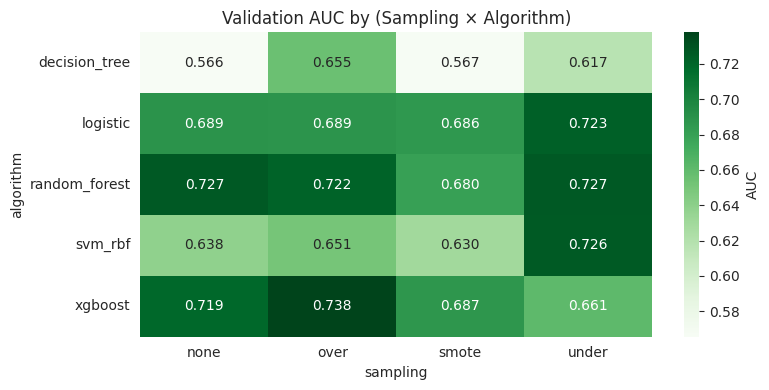

In [7]:
pv = grid.pivot(index='algorithm', columns='sampling', values='auc')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pv, annot=True, fmt=".3f", cmap="Greens", ax=ax, cbar_kws={'label':'AUC'})
ax.set_title("Validation AUC by (Sampling × Algorithm)")
plt.tight_layout(); plt.show()

## 8. Lock the winner, evaluate on the held-out test set

In [8]:
winner = grid.sort_values('auc', ascending=False).iloc[0]
print("Winner on validation:", winner[['sampling','algorithm','auc','f1']].to_dict())

s = SAMPLERS[winner['sampling']]
if s is None:
    Xtrf, ytrf = Xtr, y_train
else:
    Xtrf, ytrf = s.fit_resample(Xtr, y_train)

best_model = ALGORITHMS[winner['algorithm']]()
best_model.fit(Xtrf, ytrf)

test_metrics = evaluate(best_model, Xte, y_test)
print("\nTEST set performance:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.3f}")
test_proba = best_model.predict_proba(Xte)[:,1]

Winner on validation: {'sampling': 'over', 'algorithm': 'xgboost', 'auc': 0.7378542510121457, 'f1': 0.23529411764705882}



TEST set performance:
  f1: 0.238
  precision: 0.217
  recall: 0.263
  auc: 0.587


## 9. Lift by decile

We sort the test set by predicted probability, split into deciles, and compute response rate per decile vs the overall base rate. The **cumulative lift** tells the campaign manager: *"if we target the top 30% of scored customers, we capture X% of total responders at Y× the base rate."*

In [9]:
def lift_decile_table(y_true, y_proba, n_buckets=10):
    df = pd.DataFrame({'y': y_true, 'p': y_proba}).sort_values('p', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, n_buckets, labels=False) + 1
    base_rate = df['y'].mean()
    g = df.groupby('decile').agg(
        n=('y','size'),
        responders=('y','sum'),
    )
    g['response_rate'] = g['responders'] / g['n']
    g['lift']         = g['response_rate'] / base_rate
    g['cum_responders'] = g['responders'].cumsum()
    g['cum_n']          = g['n'].cumsum()
    g['cum_response_rate'] = g['cum_responders'] / g['cum_n']
    g['cum_lift']        = g['cum_response_rate'] / base_rate
    g['capture_rate']    = g['cum_responders'] / df['y'].sum()
    return g.reset_index()

lift = lift_decile_table(y_test, test_proba)
print(f"Base rate: {y_test.mean()*100:.1f}%")
lift.round(3)

Base rate: 10.9%


,decile,n,responders,response_rate,lift,cum_responders,cum_n,cum_response_rate,cum_lift,capture_rate
0,1,18,4,0.222,2.047,4,18,0.222,2.047,0.211
1,2,17,2,0.118,1.084,6,35,0.171,1.579,0.316
2,3,18,3,0.167,1.535,9,53,0.170,1.564,0.474
3,4,17,2,0.118,1.084,11,70,0.157,1.447,0.579
4,5,18,1,0.056,0.512,12,88,0.136,1.256,0.632
5,6,17,0,0.000,0.000,12,105,0.114,1.053,0.632
6,7,17,1,0.059,0.542,13,122,0.107,0.981,0.684
7,8,18,3,0.167,1.535,16,140,0.114,1.053,0.842
8,9,17,1,0.059,0.542,17,157,0.108,0.997,0.895
9,10,18,2,0.111,1.023,19,175,0.109,1.000,1.000


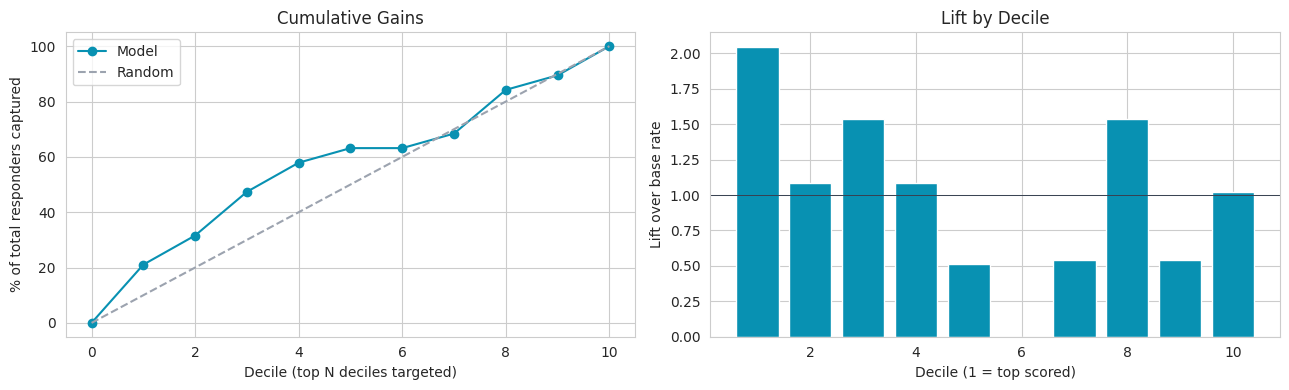

In [10]:
# Cumulative gains + lift chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot([0]+list(lift['decile']), [0]+list(lift['capture_rate']*100), marker='o', color='#0891B2', label='Model')
axes[0].plot([0,10],[0,100], '--', color='#9CA3AF', label='Random')
axes[0].set_xlabel("Decile (top N deciles targeted)")
axes[0].set_ylabel("% of total responders captured")
axes[0].set_title("Cumulative Gains")
axes[0].legend()

axes[1].bar(lift['decile'], lift['lift'], color='#0891B2')
axes[1].axhline(1, color='#374151', lw=0.7)
axes[1].set_xlabel("Decile (1 = top scored)")
axes[1].set_ylabel("Lift over base rate")
axes[1].set_title("Lift by Decile")
plt.tight_layout(); plt.show()

## 10. Operational read

If we send the comeback voucher to **the top 30% of scored customers**, we capture the lift shown above at a fraction of the cost of mass-sending. Decision threshold should be set by **expected profit** — voucher cost × responders − margin loss × non-responders.

## Discussion prompts

1. Did sampling actually move AUC, or did a strong model recover signal without it? When is sampling worth the complexity?
2. Why is **Recall** the more honest metric for this problem than Accuracy?
3. How would you set the **decision threshold** (top-N% to target) to maximize profit?
4. Imagine the response rate were 1% instead of 11% — which sampler would matter most?

**Next:** Module 4 — customer single view, segmentation, and a recommendation engine.